# DBSCAN

В этом ноутбуке узнаем:

- как DBSCAN объединяет точки в кластеры
- почему он умеет находить кластеры произвольной формы
- что означают параметры `eps` и `min_samples`
- чем отличаются core, border и noise-точки
- как DBSCAN работает с выбросами
- почему K-Means плохо справляется с несферическими кластерами
- как выбирать `eps` с помощью K-distance plot
- как оценивать качество кластеризации с учётом шума

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from matplotlib.patches import Circle

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Что такое `eps` и `min_samples`

У DBSCAN всего два главных параметра:

- **`eps`** — радиус окрестности вокруг точки. Если в этом радиусе достаточно соседей — точка считается «плотной».
- **`min_samples`** — минимальное число точек в радиусе `eps`, чтобы точка стала **core point** (ядровой).

Типы точек в DBSCAN:
- **Core point** — в её `eps`-окрестности есть хотя бы `min_samples` точек.
- **Border point** — попадает в окрестность core-точки, но сама не core.
- **Noise (шум)** — не core и не border. Получает метку `-1`.

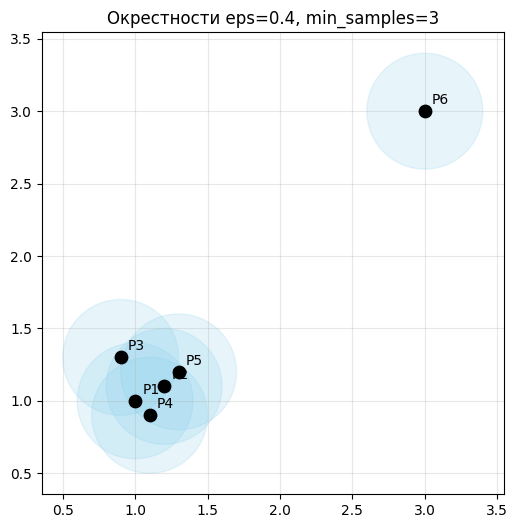

In [2]:
pts = np.array([
    [1.0, 1.0], [1.2, 1.1], [0.9, 1.3], [1.1, 0.9], [1.3, 1.2],
    [3.0, 3.0],
])

eps_demo = 0.4
min_samples_demo = 3

fig, ax = plt.subplots(figsize=(7, 6))
for i, p in enumerate(pts):
    circle = Circle(p, eps_demo, color='skyblue', alpha=0.2)
    ax.add_patch(circle)
ax.scatter(pts[:, 0], pts[:, 1], s=80, color='black', zorder=3)
for i, p in enumerate(pts):
    ax.annotate(f'P{i+1}', (p[0]+0.05, p[1]+0.05))

ax.set_title(f'Окрестности eps={eps_demo}, min_samples={min_samples_demo}')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.show()

## 2. Как DBSCAN находит плотные области

Возьмём «луны» — данные, где K-Means точно не справится.

Найдено кластеров: 2
Шумовых точек: 0


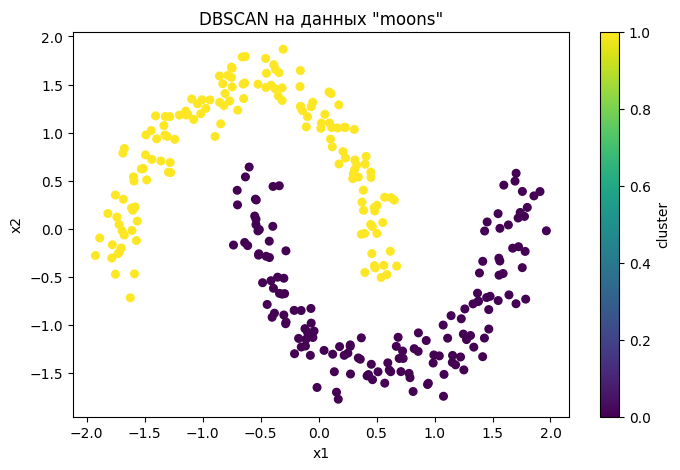

In [3]:
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.3, min_samples=5).fit(X)
labels = db.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'Найдено кластеров: {n_clusters}')
print(f'Шумовых точек: {n_noise}')

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title('DBSCAN на данных "moons"')
plt.xlabel('x1'); plt.ylabel('x2')
plt.colorbar(label='cluster')
plt.show()

## 3. Как DBSCAN определяет шумовые точки

Точки, у которых в радиусе `eps` меньше `min_samples` соседей и которые не попадают в окрестность ни одной core-точки — это шум (метка `-1`).

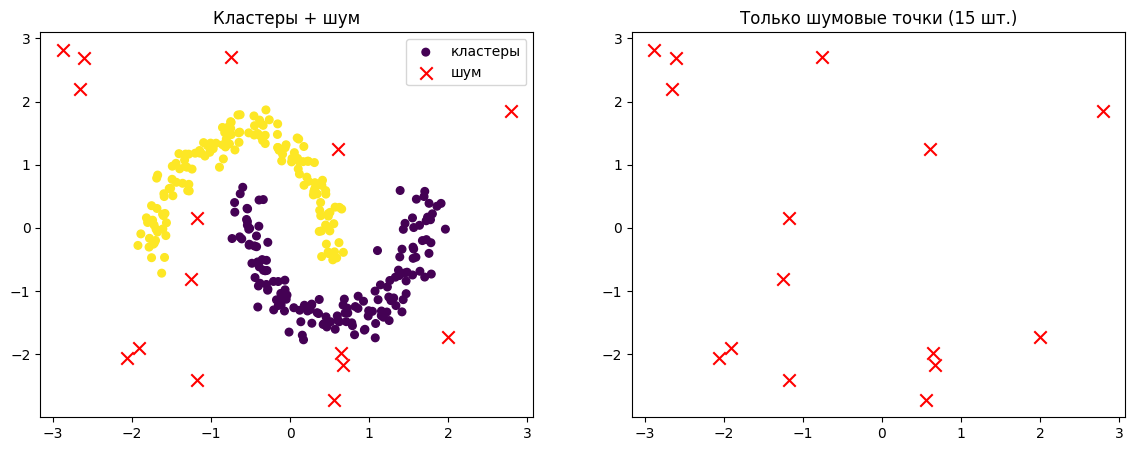

In [4]:
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-3, high=3, size=(20, 2))
X_noisy = np.vstack([X, outliers])

db = DBSCAN(eps=0.3, min_samples=5).fit(X_noisy)
labels = db.labels_

is_noise = labels == -1
is_core = np.zeros_like(labels, dtype=bool)
is_core[db.core_sample_indices_] = True

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_noisy[~is_noise, 0], X_noisy[~is_noise, 1],
                c=labels[~is_noise], cmap='viridis', s=30, label='кластеры')
axes[0].scatter(X_noisy[is_noise, 0], X_noisy[is_noise, 1],
                c='red', marker='x', s=80, label='шум')
axes[0].set_title('Кластеры + шум')
axes[0].legend()

axes[1].scatter(X_noisy[is_noise, 0], X_noisy[is_noise, 1],
                c='red', marker='x', s=80)
axes[1].set_title(f'Только шумовые точки ({is_noise.sum()} шт.)')
axes[1].set_xlim(axes[0].get_xlim()); axes[1].set_ylim(axes[0].get_ylim())

plt.show()

## 4. DBSCAN vs K-Means

K-Means строит сферические кластеры и заставляет каждую точку куда-то попасть. DBSCAN такого не делает.

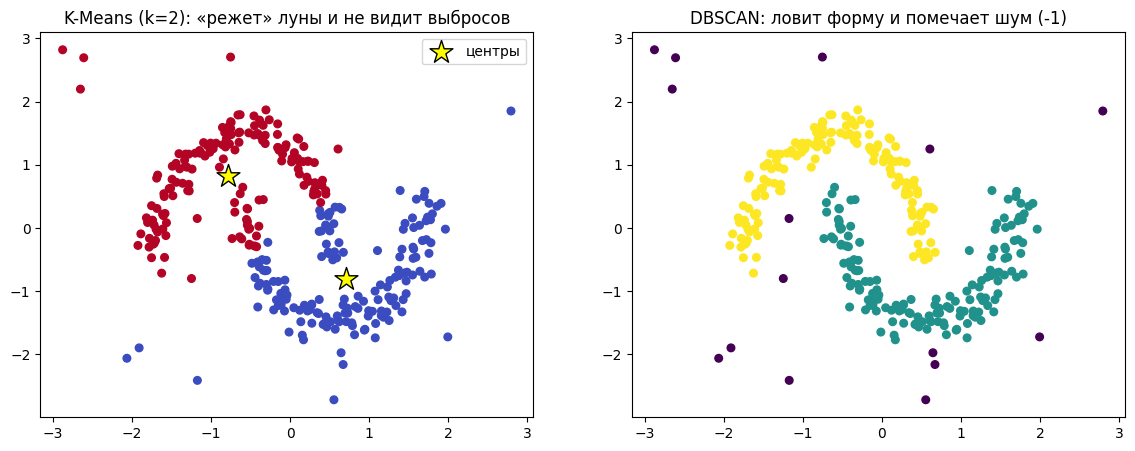

In [5]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_noisy)
db = DBSCAN(eps=0.3, min_samples=5).fit(X_noisy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_noisy[:, 0], X_noisy[:, 1], c=km.labels_, cmap='coolwarm', s=30)
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                marker='*', s=300, c='yellow', edgecolor='black', label='центры')
axes[0].set_title('K-Means (k=2): «режет» луны и не видит выбросов')
axes[0].legend()

axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], c=db.labels_, cmap='viridis', s=30)
axes[1].set_title('DBSCAN: ловит форму и помечает шум (-1)')

plt.show()

## 5. Сравнение разных `eps`

Параметр `eps` критичен: слишком маленький — всё станет шумом; слишком большой — все точки сольются в один кластер.

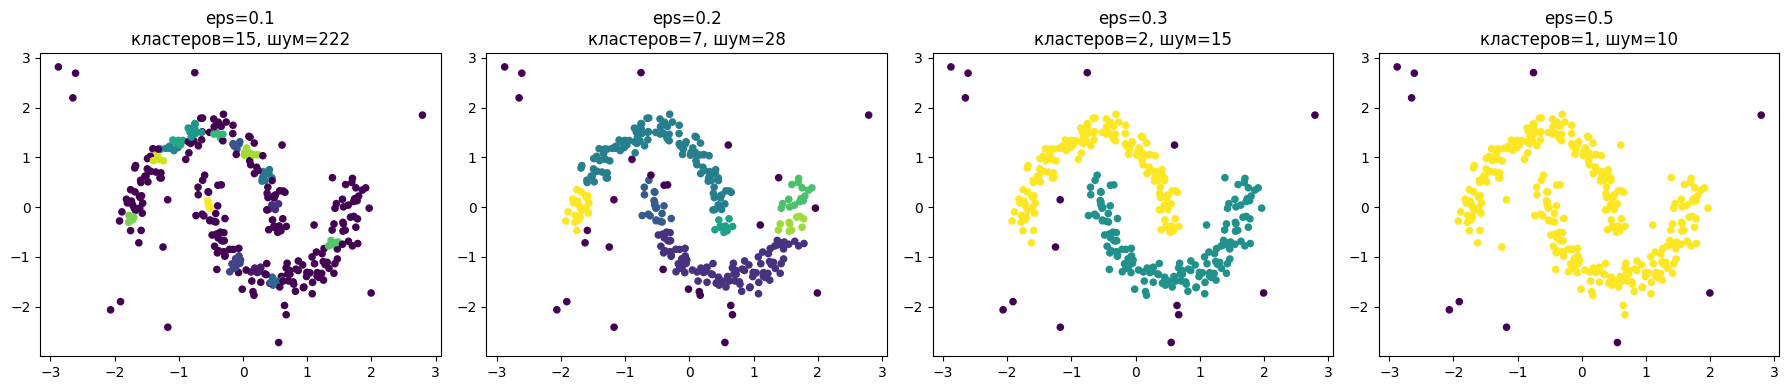

In [6]:
eps_values = [0.1, 0.2, 0.3, 0.5]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5).fit(X_noisy)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=db.labels_, cmap='viridis', s=20)
    ax.set_title(f'eps={eps}\nкластеров={n_clusters}, шум={n_noise}')

plt.tight_layout()
plt.show()

## 6. K-distance plot — как подобрать `eps`

Идея: для каждой точки считаем расстояние до её `k`-го ближайшего соседа (`k = min_samples`), сортируем и ищем «локоть» — это и есть хороший `eps`.

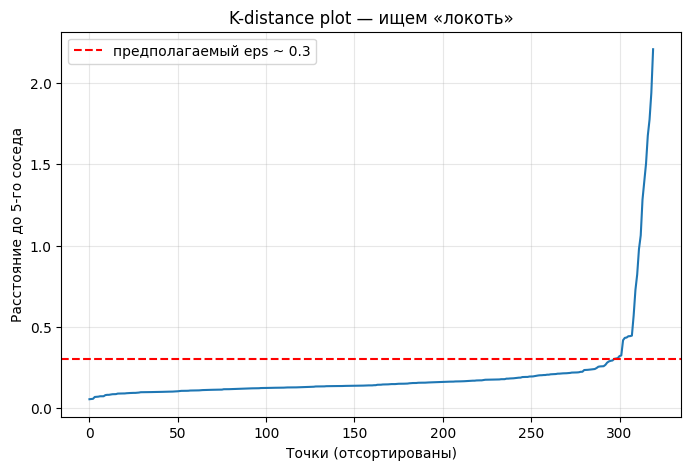

In [7]:
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_noisy)
distances, _ = nbrs.kneighbors(X_noisy)
k_distances = np.sort(distances[:, k - 1])

plt.plot(k_distances)
plt.axhline(0.3, color='red', linestyle='--', label='предполагаемый eps ~ 0.3')
plt.xlabel('Точки (отсортированы)')
plt.ylabel(f'Расстояние до {k}-го соседа')
plt.title('K-distance plot — ищем «локоть»')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Метрики качества кластеризации

- **Silhouette Score** — чем ближе к 1, тем лучше (диапазон [-1, 1]).
- **Davies-Bouldin Score** — чем **меньше**, тем лучше (от 0).
- **Calinski-Harabasz Score** — чем **больше**, тем лучше.

**Важно:** считаем метрики только если найдено хотя бы 2 кластера, и считаем их **без учёта шума**.

In [8]:
def evaluate_dbscan(X, labels):
    mask = labels != -1
    X_clean, labels_clean = X[mask], labels[mask]
    n_clusters = len(set(labels_clean))

    if n_clusters < 2:
        print(f'Найдено {n_clusters} кластеров без учёта шума — метрики не считаем.')
        return None

    return {
        'n_clusters': n_clusters,
        'n_noise': int((labels == -1).sum()),
        'silhouette': silhouette_score(X_clean, labels_clean),
        'davies_bouldin': davies_bouldin_score(X_clean, labels_clean),
        'calinski_harabasz': calinski_harabasz_score(X_clean, labels_clean),
    }

results = []
for eps in [0.1, 0.2, 0.3, 0.5]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_noisy)
    metrics = evaluate_dbscan(X_noisy, db.labels_)
    if metrics is not None:
        metrics = {'eps': eps, **metrics}
        results.append(metrics)

df = pd.DataFrame(results)
df

Найдено 1 кластеров без учёта шума — метрики не считаем.


,eps,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,0.1,15,222,0.675622,0.383531,1534.057672
1,0.2,7,28,0.221606,0.841420,157.536272
2,0.3,2,15,0.379637,1.028675,258.255125


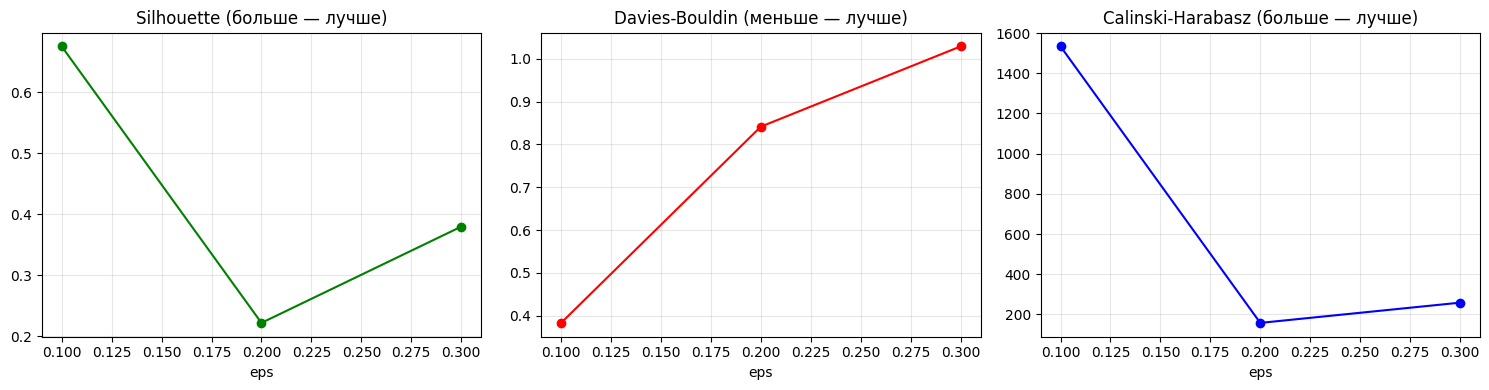

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['eps'], df['silhouette'], 'o-', color='green')
axes[0].set_title('Silhouette (больше — лучше)')
axes[0].set_xlabel('eps'); axes[0].grid(alpha=0.3)

axes[1].plot(df['eps'], df['davies_bouldin'], 'o-', color='red')
axes[1].set_title('Davies-Bouldin (меньше — лучше)')
axes[1].set_xlabel('eps'); axes[1].grid(alpha=0.3)

axes[2].plot(df['eps'], df['calinski_harabasz'], 'o-', color='blue')
axes[2].set_title('Calinski-Harabasz (больше — лучше)')
axes[2].set_xlabel('eps'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#**Общий итог:**

- DBSCAN отлично работает там, где кластеры имеют **сложную форму** и присутствует **шум**.
- Главное — правильно подобрать `eps` (помогает k-distance plot) и `min_samples`.
- Метрики кластеризации считаем только при **>= 2 кластеров без учёта шума**.